<a href="https://colab.research.google.com/github/HeaDShoT4iK/AsilbekKI/blob/main/LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

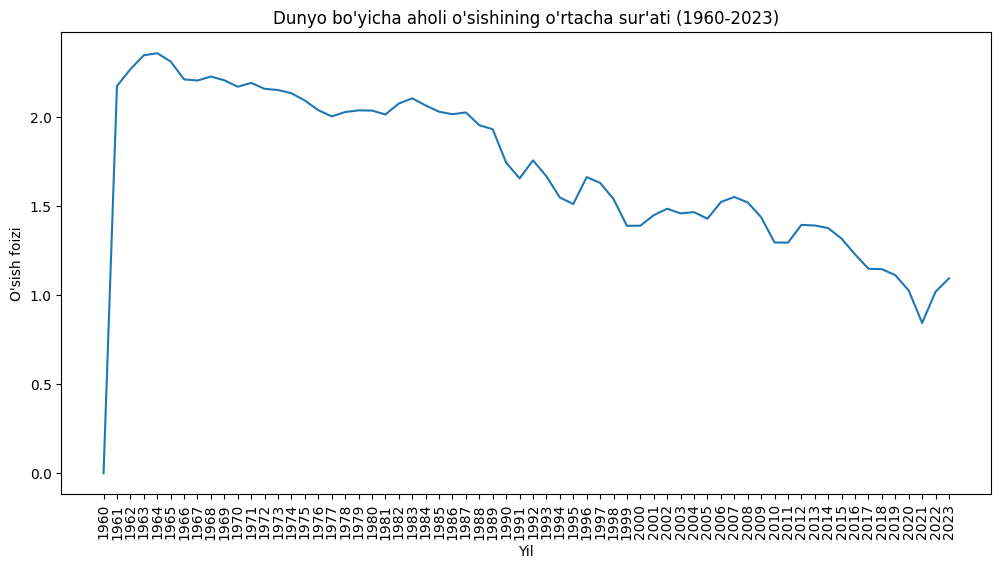

In [3]:
# 2. Visualization (Matplotlib)
plt.figure(figsize=(12, 6))
# Dunyo bo'yicha o'rtacha o'sish tendensiyasi
world_avg = df_numeric.mean()
sns.lineplot(x=world_avg.index, y=world_avg.values)
plt.xticks(rotation=90)
plt.title("Dunyo bo'yicha aholi o'sishining o'rtacha sur'ati (1960-2023)")
plt.xlabel("Yil")
plt.ylabel("O'sish foizi")
plt.show()

In [2]:
from google.colab import files
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Yuklangan faylni to'g'ri o'qish (dastlabki 4 qatorni tashlab yuboramiz)
for filename in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[filename]), skiprows=4)
    print(f'"{filename}" muvaffaqiyatli yuklandi.')

# 1. Preprocessing (Tozalash)
# Keraksiz ustunlarni olib tashlaymiz
df_cleaned = df.drop(columns=['Unnamed: 68', 'Indicator Name', 'Indicator Code'], errors='ignore')

# Model uchun faqat raqamli yillarni tanlaymiz va NaN qiymatlarni to'ldiramiz
years = [str(year) for year in range(1960, 2024) if str(year) in df_cleaned.columns]
df_numeric = df_cleaned[years].fillna(method='ffill', axis=1).fillna(0)

display(df_cleaned.head())

"API_SP.POP.GROW_DS2_en_csv_v2_593.csv" muvaffaqiyatli yuklandi.


/tmp/ipykernel_166/3926168878.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_numeric = df_cleaned[years].fillna(method='ffill', axis=1).fillna(0)


,Country Name,Country Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,NaN,1.187344,1.326227,1.203664,1.076602,0.986114,0.862399,0.503043,...,0.007358,0.158976,0.270505,-0.565684,-0.820211,-0.362774,0.045652,0.590657,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,2.624624,2.687009,2.714042,2.769856,2.809882,2.810324,2.844811,...,2.642067,2.734263,2.721681,2.699516,2.649439,2.592754,2.519167,2.472801,NaN,NaN
2,Afghanistan,AFG,NaN,1.962239,2.044523,2.105208,2.161195,2.233709,2.269651,2.306668,...,2.808337,2.910810,2.984389,3.153609,2.356098,1.435704,2.135594,2.836573,NaN,NaN
3,Africa Western and Central,AFW,NaN,2.103832,2.131522,2.170015,2.184894,2.216283,2.249277,2.264622,...,2.626296,2.533621,2.440048,2.389176,2.363829,2.332270,2.386204,2.398473,NaN,NaN
4,Angola,AGO,NaN,1.327797,0.989639,1.003666,1.027684,1.052133,1.070046,1.076727,...,3.540612,3.453233,3.387884,3.267959,3.181323,3.143026,3.080655,3.044200,NaN,NaN


# 3. Decision Tree Regression
# Misol tariqasida: 2022-yil ma'lumotlari asosida 2023-yilni bashorat qilish
X = df_numeric[['2022']]
y = df_numeric['2023']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# Natijalarni solishtirish
plt.scatter(X_test, y_test, color='blue', label='Asl qiymat')
plt.scatter(X_test, y_pred, color='red', label='Bashorat')
plt.legend()
plt.title("Decision Tree Regression Natijalari")
plt.show()